In [3]:
import matplotlib.pyplot as plt 
import numpy as np

In [4]:

epochs = [1,2,3]
train_loss = [2.4357, 2.0215, 1.8718]

eval_loss = [2.0904, 1.9250, 1.8335]

perplexity = [8.09, 6.86, 6.26]

learning_rate = [0.00099441, 0.00046263, 0.00005000]

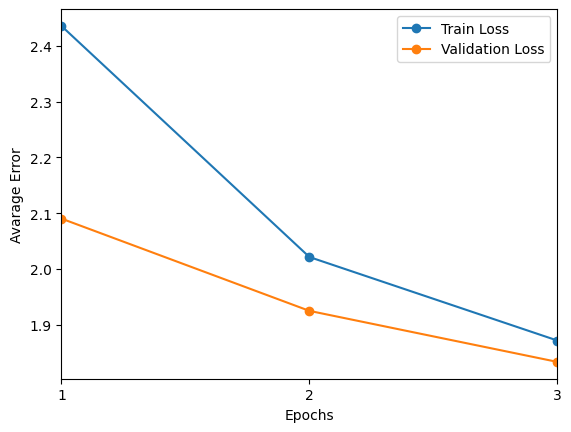

In [9]:
plt.plot(epochs,np.array(train_loss),marker='o',label='Train Loss')
plt.plot(epochs,np.array(eval_loss),marker='o',label='Validation Loss')
plt.xlim(1,3)
plt.xticks(range(1,4))
plt.xlabel('Epochs')
plt.ylabel('Avarage Error')

plt.legend()
plt.show()

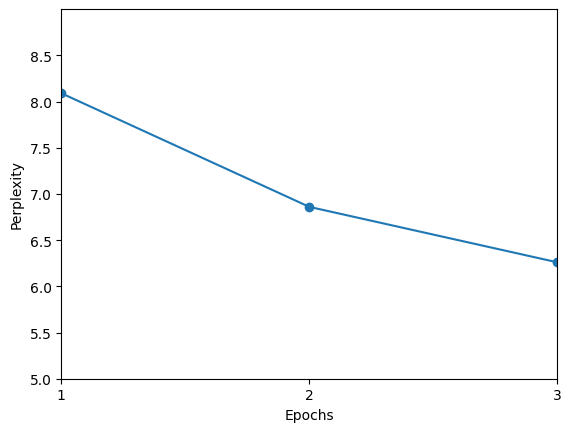

In [11]:
plt.plot(epochs,perplexity,marker='o',label='Perplexity')
plt.xlim(1,3)
plt.ylim(5,9)
plt.xticks(range(1,4))
plt.yticks(np.arange(5.0, 9.0, 0.5))
plt.xlabel('Epochs')
plt.ylabel('Perplexity')
plt.show()

In [12]:
dialogues = [
    {"input": "Once upon a time there was this planet", "output": "once upon a time there was this planet. it was very big and very big. one day, a little girl named lucy wanted to explore the planet. she asked her mom if she could go. her mom said yes, so lucy ran outside. she saw the big planet and it was very big. she wanted to explore it. so lucy started to climb the big planet. she climbed and climbed until she reached the top. she looked around and saw lots of things. she saw a big tree and some birds flying in the sky. she was so happy! lucy kept climbing until she reached the top. she looked around and saw the big planet. she was so excited! she wanted to explore it. so she climbed down the big planet and ran back home. she had a lot of fun exploring the big planet."},
    {"input": "There was a strom", "output": "there was a storm. it was very loud and scary. the wind was blowing and the rain was pouring down. the wind was so strong that it made the rain drop down. the rain was so strong that it made the ground shake. the rain was so strong that it made the ground shake. the rain was so strong that it made the ground shake even harder. the rain kept falling and the ground shook even harder. the rain kept falling and the ground shook even harder. the rain kept falling and the ground shook even harder. the rain kept falling and the ground shook even harder. the rain kept falling and the ground shook even harder. the rain kept falling and the ground shook until it was so heavy that it was almost like it was shaking. the rain stopped and the sun came out. the ground was still shaking, but the ground was still shaking. the storm was so strong that it made the ground shake even harder. the rain stopped and the ground was quiet again. the sun came out and the ground was dry again. the ground was still shaking, but the ground was still shaking."},
   
  
]


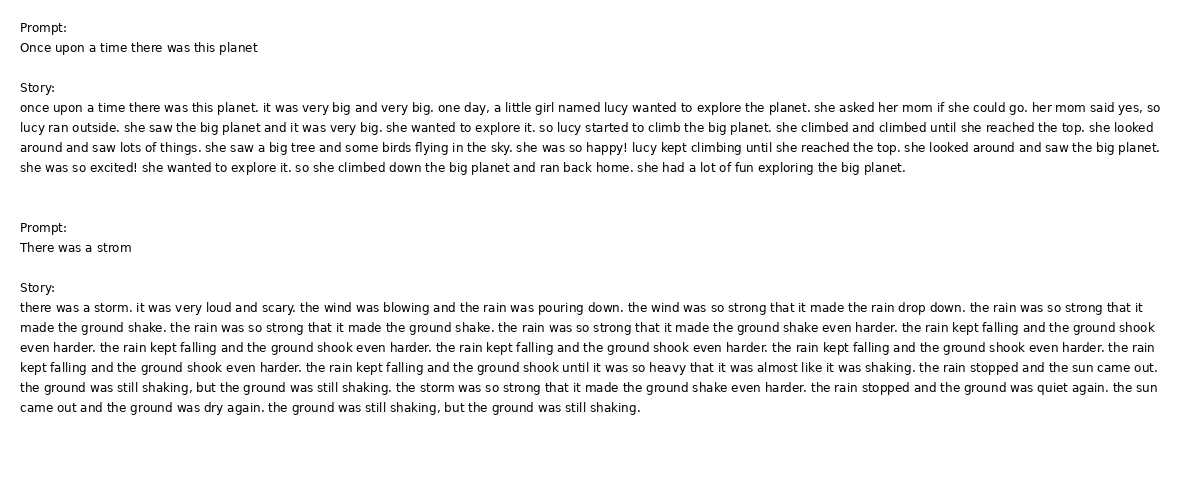

In [14]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

inputs = [d['input'] for d in dialogues]
outputs = [d['output'] for d in dialogues]

try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 12)
except:
    font = ImageFont.load_default()

def wrap_text(text, font, max_width):
    lines = []
    words = text.split()
    current_line = []
    
    for word in words:
        test_line = ' '.join(current_line + [word])
        bbox = draw.textbbox((0, 0), test_line, font=font)
        width = bbox[2] - bbox[0]
        
        if width <= max_width:
            current_line.append(word)
        else:
            if current_line:
                lines.append(' '.join(current_line))
            current_line = [word]
    
    if current_line:
        lines.append(' '.join(current_line))
    
    return lines

# First pass: calculate total height needed
max_width = 1150
total_height = 20
temp_img = Image.new('RGB', (1200, 1), color='white')
temp_draw = ImageDraw.Draw(temp_img)
draw = temp_draw

for inp, out in zip(inputs, outputs):
    total_height += 20  # Prompt label
    total_height += len(wrap_text(inp, font, max_width)) * 20  # Input lines
    total_height += 40  # Space
    total_height += 20  # Story label
    total_height += len(wrap_text(out, font, max_width)) * 20  # Output lines
    total_height += 40  # Space between dialogues

# Create image with calculated height
img = Image.new('RGB', (1200, total_height), color='white')
draw = ImageDraw.Draw(img)

y_position = 20

for inp, out in zip(inputs, outputs):
    draw.text((20, y_position), "Prompt:", fill='black', font=font)
    y_position += 20
    
    input_lines = wrap_text(inp, font, max_width)
    for line in input_lines:
        draw.text((20, y_position), line, fill='black', font=font)
        y_position += 20
    
    y_position += 20
    draw.text((20, y_position), "Story:", fill='black', font=font)
    y_position += 20
    
    output_lines = wrap_text(out, font, max_width)
    for line in output_lines:
        draw.text((20, y_position), line, fill='black', font=font)
        y_position += 20
    
    y_position += 40

display(img)